In [ ]:
import numpy as np
import pandas as pd
import time

# dataset source
https://www.kaggle.com/datasets/akram24/social-network-ads?resource=download

In [ ]:
df = pd.read_csv('Social_Network_Ads.csv')

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df = df[['Age','EstimatedSalary','Purchased']]

In [ ]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled.shape

(400, 2)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

## 1. Batch Gradient Descent

- Uses **all training data** in one go to compute the gradient
- Slow for large datasets, but stable convergence
- `batch_size = total samples (400)`

In [ ]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history = model.fit(X_scaled,y,epochs=500,batch_size=400,validation_split=0.2)
#print(time.time() - start)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9094 - loss: 0.2654 - val_accuracy: 0.9750 - val_loss: 0.1530
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9125 - loss: 0.2608 - val_accuracy: 0.9625 - val_loss: 0.1569
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9125 - loss: 0.2578 - val_accuracy: 0.9625 - val_loss: 0.1602
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9125 - loss: 0.2555 - val_accuracy: 0.9625 - val_loss: 0.1633
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9125 - loss: 0.2534 - val_accuracy: 0.9625 - val_loss: 0.1662
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9125 - loss: 0.2515 - val_accuracy: 0.9625 - val_loss: 0.1689
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9125 - loss: 0.2498 - val_accuracy: 0.9625 - val_loss: 0.1716
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9125 - loss: 0.2483 - val_accuracy: 0.9625 - val_lo

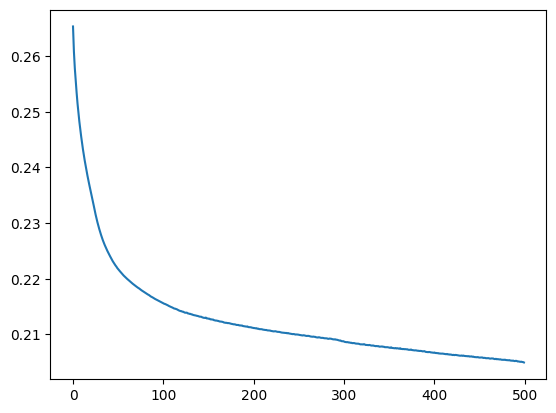

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])


## 3. Mini-Batch Gradient Descent

- Uses a **small batch** of samples each step
- Best of both worlds — faster than batch, smoother than SGD
- `batch_size = 32` (common default)

In [ ]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history = model.fit(X_scaled,y,epochs=300,batch_size=250,validation_split=0.2)
#print(time.time() - start)

Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.8196 - loss: 0.4684 - val_accuracy: 0.7500 - val_loss: 0.5386
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8156 - loss: 0.4649 - val_accuracy: 0.7625 - val_loss: 0.5320
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8102 - loss: 0.4585 - val_accuracy: 0.7750 - val_loss: 0.5268
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8137 - loss: 0.4551 - val_accuracy: 0.7750 - val_loss: 0.5252
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8123 - loss: 0.4539 - val_accuracy: 0.7625 - val_loss: 0.5241
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8211 - loss: 0.4435 - val_accuracy: 0.7625 - val_loss: 0.5209
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8171 - loss: 0.4438 - val_accuracy: 0.7500 - val_loss: 0.5213
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8123 - loss: 0.4412 - val_accuracy: 0.7500 - val_loss

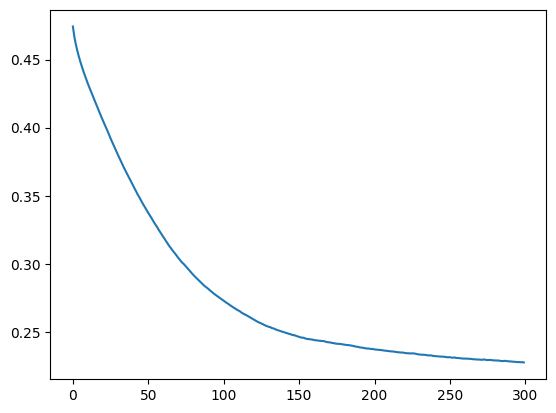

In [ ]:
plt.plot(history.history['loss'])

## 2. Stochastic Gradient Descent (SGD)

- Uses **one sample at a time** to compute the gradient
- Fast updates, but noisy (loss curve is bumpy)
- `batch_size = 1`

In [ ]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history = model.fit(X_scaled,y,epochs=300,batch_size=1,validation_split=0.2)
#print(time.time() - start)